# Momentum-resolved spectral functions
`get_kdos_bands` broadens the discrete band structure into a continuous spectral function
$A(\mathbf k,\omega)=\sum_n \delta_\delta(\omega-\epsilon_{n\mathbf k})\,|\langle\psi_{n\mathbf
k}|\hat O|\psi_{n\mathbf k}\rangle|^2$ on a $(\mathbf k,\omega)$ grid, optionally projected with an
operator. Projecting a BdG Hamiltonian onto `operator="electron"` recovers the electron-sector
spectral weight, useful once superconducting pairing mixes electron and hole character.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import islands

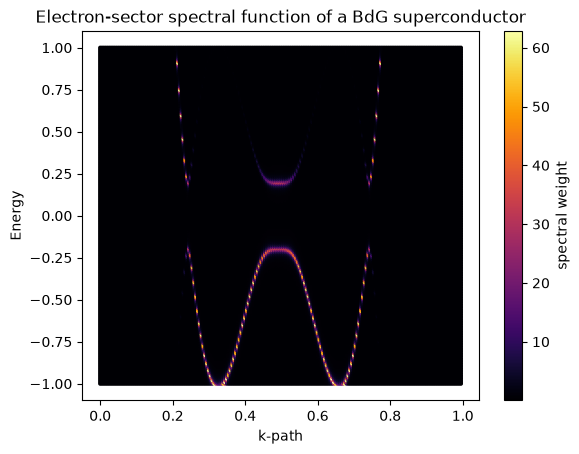

In [2]:
g = geometry.triangular_lattice()
h = g.get_hamiltonian()
h.setup_nambu_spinor()
h = h.get_mean_field_hamiltonian(U=-1.0,filling=0.15,mf="swave") # SCF s-wave pairing

(k,e,d) = h.get_kdos_bands(operator="electron",nk=200,delta=1e-2,
                            energies=np.linspace(-1.0,1.0,200))

plt.scatter(k,e,c=d,cmap="inferno",s=4)
plt.colorbar(label="spectral weight")
plt.xlabel("k-path") ; plt.ylabel("Energy")
plt.title("Electron-sector spectral function of a BdG superconductor")
plt.show()